# import thư viện

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# data

In [ ]:
file_path = "groundtruth_inference.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(3025, 5)


,domain,question,answers,correct_answer,pred_label
0,HinhSu,Trách nhiệm chứng minh tội phạm thuộc về ai?,['Trách nhiệm chứng minh tội phạm thuộc về Tòa...,2,2
1,HinhSu,Quyền bào chữa của người bị buộc tội được quy ...,"['Người bị buộc tội có nghĩa vụ tự bào chữa, h...",3,3
2,HinhSu,"Trách nhiệm của cơ quan, người có thẩm quyền t...","['Trong quá trình tiến hành tố tụng, cơ quan n...",3,3
3,HinhSu,"Tính mạng, sức khoẻ, danh dự, nhân phẩm, tài s...","['Mọi hành vi xâm phạm tính mạng, sức khoẻ, da...",3,3
4,HinhSu,Người bị tạm giữ có quyền gì?,['Được biết lý do mình bị tạm giữ; nhận quyết ...,3,3


# Tách tập đúng/sai

In [ ]:
df_error = df[df["correct_answer"] != df["pred_label"]].copy()
df_correct = df[df["correct_answer"] == df["pred_label"]].copy()

print("Total:", len(df))
print("Correct:", len(df_correct))
print("Wrong:", len(df_error))


error_rate = len(df_error) / len(df)

print(f"Error rate: {error_rate:.2%}")

Total: 3025
Correct: 1742
Wrong: 1283
Error rate: 42.41%


# Error rate theo domain

In [ ]:
domain_error = (
    df.groupby("domain")
    .apply(lambda x: pd.Series({
            "total": len(x),
            "wrong": (x.correct_answer != x.pred_label).sum(),
            "error_rate":
            (x.correct_answer != x.pred_label).mean()
        })
    )
    .sort_values("error_rate", ascending=False)
)


domain_error

/tmp/ipykernel_5791/591584778.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,total,wrong,error_rate
domain,,,
KinhDoanhBatDongSan,28.0,15.0,0.535714
DuLich,240.0,122.0,0.508333
DatDai,240.0,117.0,0.487500
GiaoDichDienTu,35.0,17.0,0.485714
HinhSu,305.0,145.0,0.475410
SoHuuTriTue,22.0,10.0,0.454545
CongChung,20.0,9.0,0.450000
LaoDong,350.0,156.0,0.445714
ToTungDanSu,163.0,72.0,0.441718


# Confusion matrix

In [ ]:
confusion = pd.crosstab(
    df_error["correct_answer"],
    df_error["pred_label"],
    rownames=["Correct"],
    colnames=["Prediction"]
)


confusion

Prediction,0,1,2,3
Correct,,,,
0,0,168,70,85
1,407,0,59,57
2,51,66,0,88
3,76,77,79,0


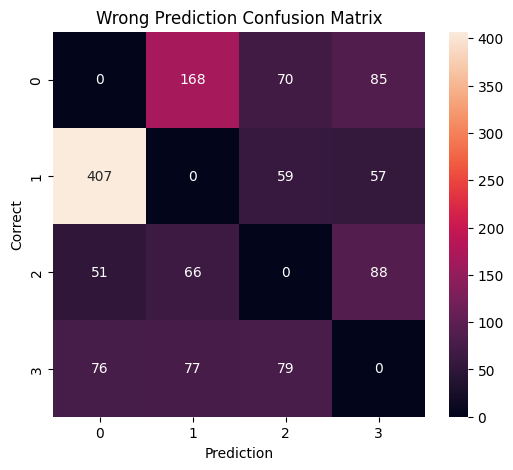

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion, annot=True, fmt="d")

plt.title("Wrong Prediction Confusion Matrix")

plt.show()

#Kiểm tra model có bias chọn đáp án không

In [ ]:
pred_bias = (df_error["pred_label"].value_counts().sort_index())

pred_bias

,count
pred_label,
0,534
1,311
2,208
3,230


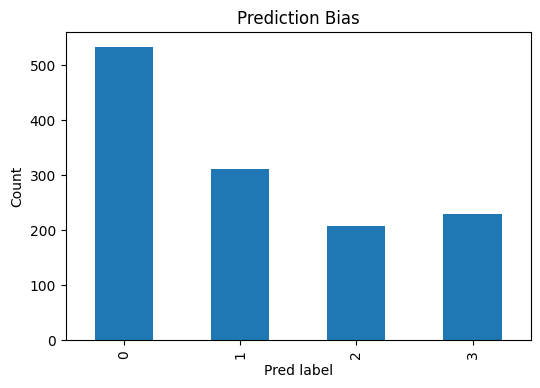

In [ ]:
pred_bias.plot(kind="bar", figsize=(6,4), title="Prediction Bias")

plt.xlabel("Pred label")
plt.ylabel("Count")
plt.show()

# Độ dài câu hỏi

In [ ]:
df["question_length"] = (df["question"].astype(str).apply(len))
df["answer_length"] = (df["answers"].astype(str).apply(len))

df.groupby(df.correct_answer != df.pred_label)[["question_length", "answer_length"]].mean()

,question_length,answer_length
False,89.588404,192.623995
True,89.170694,189.646921


# Tìm câu có đáp án lựa chọn bị trùng

In [ ]:
def check_duplicate_answer(x):

    try:
        answers = ast.literal_eval(x)
        answers = [a.strip().lower() for a in answers]

        return len(answers) != len(set(answers))

    except:
        return False



df["duplicate_option"] = (df["answers"].apply(check_duplicate_answer))
duplicate_error = df_error[df["duplicate_option"]]
print(len(duplicate_error))

duplicate_error[["question", "answers", "correct_answer", "pred_label"]]

7


/tmp/ipykernel_5791/1983653473.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicate_error = df_error[df["duplicate_option"]]


,question,answers,correct_answer,pred_label
7,"Thẩm phán, Hội thẩm xét xử theo nguyên tắc nào?","['Xét xử độc lập và chỉ tuân theo pháp luật', ...",3,0
62,Đồng phạm là gì?,['Đồng phạm là trường hợp có một nhóm người cố...,3,1
246,Thời giờ làm việc của người lao động trong điề...,"['Theo Luật Lao động hiện hành, thời giờ làm v...",0,3
567,Trường hợp người bị phạt cải tạo không giam gi...,['Không quá 02 giờ trong một ngày và không quá...,1,3
2271,Yêu cầu về nội dung giáo dục?,"['Phát huy tính tích cực, tự giác, chủ động, t...",2,3
2283,Giáo dục phổ thông gồm:,['Giáo dục tiểu học được thực hiện trong năm h...,1,3
2786,Liên thông trong giáo dục là?,['Việc sử dụng kết quả học tập đã có để học ti...,1,0


# Kiểm tra sơ lược các dòng lỗi

In [ ]:
error_samples = (df_error[[
        "domain",
        "question",
        "answers",
        "correct_answer",
        "pred_label"
      ]
  ].sample(50,random_state=42)
)

error_samples

,domain,question,answers,correct_answer,pred_label
2948,ToTungHinhSu,Tư cách bị cáo có từ khi nào?,"['Từ khi người đó thực hiện hành vi phạm tội',...",1,3
2955,KinhDoanhBatDongSan,Cơ quan nào sau đây không có thẩm quyền cấp gi...,"['Phòng tài nguyên môi trường', 'Sở tài nguyên...",3,0
614,DanSu,Một người đang thực hiện khoản vay tín chấp mà...,"['Đúng', 'Sai']",1,0
516,HinhSu,"Xét về mặt cấu trúc, hành vi khách quan của tộ...","['Hành vi xảy ra trong thời gian ngắn', 'Hành ...",3,1
1298,LaoDong,Người lao động được nghỉ về việc riêng mà vẫn ...,"['Kết hôn, nghỉ 3 ngày', 'Con kết hôn, nghỉ 1 ...",2,1
1694,DuLich,Du lịch cộng đồng được hiểu là gì?,['Là loại hình du lịch được phát triển trên cơ...,3,2
569,HinhSu,Hình phạt nào không phải là hình phạt bổ sung ...,"['Cấm kinh doanh, cấm hoạt động trong một số l...",3,2
3002,GiaoDichDienTu,Anh A có hành vi giả mạo logo “đã thông báo” t...,['Phạt tiền từ 1.000.000 đồng đến 5.000.000 đồ...,1,2
2375,GiaoDuc,Đào tạo trình độ tiến sĩ đối với người có bằng...,"['4 năm', 'từ 1- 2 năm', 'từ 1,5 -2 năm', 'từ ...",0,3
598,DanSu,Hợp đồng mua bán là hợp đồng chỉ bao gồm hai b...,"['Đúng', 'Sai']",1,0


# Tổng hợp báo cáo nhanh

In [ ]:
report = {

"Total questions":
len(df),

"Correct":
len(df_correct),

"Wrong":
len(df_error),

"Accuracy":
len(df_correct)/len(df),

"Error rate":
len(df_error)/len(df),

"Most wrong domain":
domain_error.index[0],

"Most predicted wrong label":
pred_bias.idxmax()

}


pd.Series(report)

,0
Total questions,3025
Correct,1742
Wrong,1283
Accuracy,0.575868
Error rate,0.424132
Most wrong domain,KinhDoanhBatDongSan
Most predicted wrong label,0
